[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/allegheny-college-cmpsc-105-spring-2026/data-analytics-starter/blob/main/data_analytics.ipynb)

In [ ]:
# load pre-existing tools available for data exploration

import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact # pre existing code for interaction

In [ ]:
# Upload your downloaded CSV files to this Colab environment

# Do this by going over to the file icon on the left. Then, toward
# the top, find the file upload icon and upload your csv files.

# NOTE: the CSV file must have the exact names data_survey.csv and data_analytics.csv

In [38]:
import pandas as pd
import re

# Read the file as plain text lines
with open('/content/data_analytics.csv', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Function to extract up to 2 numbers from each line
def extract_numbers(s):
    nums = re.findall(r'\d+', s)
    if len(nums) == 0:
        return [None, None]
    elif len(nums) == 1:
        return [int(nums[0]), None]
    else:
        return [int(nums[0]), int(nums[1])]

# Apply extraction to all lines
data = [extract_numbers(line) for line in lines]

# Create a clean DataFrame
dfa_clean = pd.DataFrame(data, columns=['Nth_day', 'Active_users'])

# Drop rows where both values are None
dfa_clean = dfa_clean.dropna(how='all').reset_index(drop=True)

print(dfa_clean.head())
print("Clean analytics shape:", dfa_clean.shape)

      Nth_day  Active_users
0  20260224.0           NaN
1  20260323.0           NaN
2         0.0           0.0
3         1.0           0.0
4         2.0           0.0
Clean analytics shape: (195, 2)


In [55]:
import pandas as pd

# Step 1: Read the CSV using the first row as header
dfs = pd.read_csv('/content/data_survey.csv', header=0)

# Step 2: Rename columns to simple names
dfs.columns = ['Timestamp', 'Free_time_per_day', 'Credits_this_semester']

# Step 3: Convert credits to numeric
dfs['Credits_this_semester'] = pd.to_numeric(dfs['Credits_this_semester'], errors='coerce')

# Step 4: Map free time text to approximate numeric values
free_time_map = {'1-2 hours': 1.5, '2-3 hours': 2.5, '3-4 hours': 3.5, '4+ hours': 4.5}
dfs['Free_time_hours'] = dfs['Free_time_per_day'].map(free_time_map)

# Step 5: Check the cleaned data
print(dfs.head())

             Timestamp Free_time_per_day  Credits_this_semester  \
0  17.03.2026 15:24:23         1-2 hours                   17.0   
1  17.03.2026 15:29:19         2-3 hours                   16.0   
2  17.03.2026 15:35:32          4+ hours                   17.0   
3  17.03.2026 20:40:16         3-4 hours                   17.0   
4  19.03.2026 13:49:09         1-2 hours                   16.0   

   Free_time_hours  
0              1.5  
1              2.5  
2              4.5  
3              3.5  
4              1.5  


In [46]:
# how many rows and columns are in the dataframe dfa? (125, 1)
# how many rows and columns are in the dataframe dfs? (10, 1)

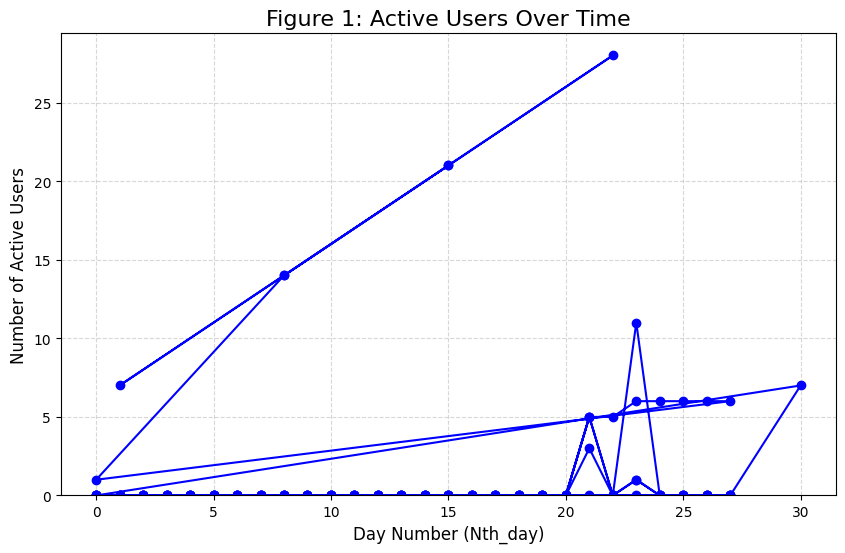

In [47]:
import matplotlib.pyplot as plt

# Make sure your numeric columns are properly typed
dfa_clean['Nth_day'] = pd.to_numeric(dfa_clean['Nth_day'], errors='coerce')
dfa_clean['Active_users'] = pd.to_numeric(dfa_clean['Active_users'], errors='coerce')

# Remove any rows with NaN (optional)
dfa_clean = dfa_clean.dropna(subset=['Nth_day', 'Active_users'])

# Figure
plt.figure(figsize=(10,6))

# Plot Active Users vs Nth Day
plt.plot(dfa_clean['Nth_day'], dfa_clean['Active_users'], marker='o', linestyle='-', color='blue')

# Titles and labels
plt.title('Figure 1: Active Users Over Time', fontsize=16)
plt.xlabel('Day Number (Nth_day)', fontsize=12)
plt.ylabel('Number of Active Users', fontsize=12)

# Optional: y-axis limits for better visualization
plt.ylim(bottom=0)  # start y-axis at 0

# Optional: grid
plt.grid(True, linestyle='--', alpha=0.5)

# Show plot
plt.show()

             Timestamp Free_time_per_day  Credits_this_semester  \
0  17.03.2026 15:24:23         1-2 hours                   17.0   
1  17.03.2026 15:29:19         2-3 hours                   16.0   
2  17.03.2026 15:35:32          4+ hours                   17.0   
3  17.03.2026 20:40:16         3-4 hours                   17.0   
4  19.03.2026 13:49:09         1-2 hours                   16.0   

   Free_time_hours  
0              1.5  
1              2.5  
2              4.5  
3              3.5  
4              1.5  


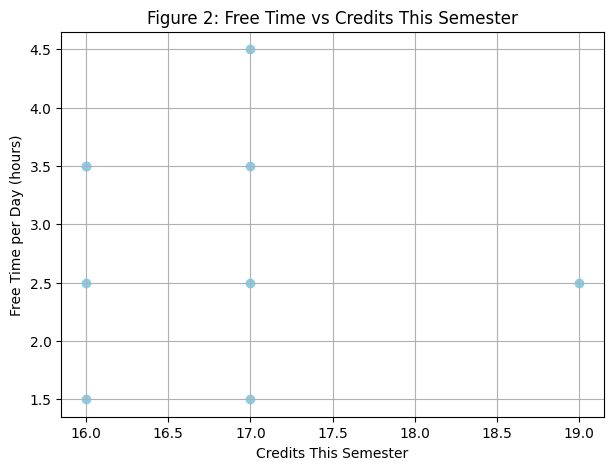

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Read raw CSV as-is
dfs_raw = pd.read_csv('/content/data_survey.csv', header=0)  # use first row as header

# Step 2: Rename columns to something simple
dfs_raw.columns = ['Timestamp', 'Free_time_per_day', 'Credits_this_semester']

# Step 3: Convert credits to numeric
dfs_raw['Credits_this_semester'] = pd.to_numeric(dfs_raw['Credits_this_semester'], errors='coerce')

# Step 4: Map free time text to numeric hours
free_time_mapping = {'1-2 hours': 1.5, '2-3 hours': 2.5, '3-4 hours': 3.5, '4+ hours': 4.5}
dfs_raw['Free_time_hours'] = dfs_raw['Free_time_per_day'].map(free_time_mapping)

# Step 5: Quick check
print(dfs_raw.head())

# Step 6: Plot
plt.figure(figsize=(7,5))
plt.scatter(dfs_raw['Credits_this_semester'], dfs_raw['Free_time_hours'], color='skyblue')
plt.title('Figure 2: Free Time vs Credits This Semester')
plt.xlabel('Credits This Semester')
plt.ylabel('Free Time per Day (hours)')
plt.grid(True)
plt.show()

In [ ]:
# When you are satisfied with your figures, write up your report in the file called report.qmd